In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
import sys, os
sys.path.insert(0, os.path.expanduser("~/sentinelmesh"))
from etl.utils.db_connect import get_engine

# Load from PostgreSQL
engine = get_engine()
df = pd.read_sql("SELECT * FROM stg_harmonized", engine)

print(f"Shape      : {df.shape}")
print(f"Columns    : {list(df.columns)}")
print(f"Classes    : {df['unified_label'].nunique()}")
print(f"\nClass counts:\n{df['unified_label'].value_counts()}")

Shape      : (452570, 32)
Columns    : ['id', 'dataset_source', 'source_file', 'sample_seed', 'phase', 'protocol', 'duration', 'src_bytes', 'dst_bytes', 'total_bytes', 'src_pkts', 'dst_pkts', 'total_pkts', 'flow_rate_byts_s', 'flow_rate_pkts_s', 'syn_flag', 'ack_flag', 'fin_flag', 'rst_flag', 'cic_iat_mean', 'cic_iat_std', 'cic_flow_pkts_s', 'cic_active_mean', 'cic_idle_mean', 'ton_conn_state', 'ton_dns_query', 'ton_http_method', 'label_raw', 'unified_label', 'attack_family', 'is_attack', 'ingest_timestamp']
Classes    : 16

Class counts:
unified_label
BenignTraffic       70000
Web-SQLi            45245
Malware-Backdoor    43218
Recon-PortScan      40000
BruteForce-Dict     33064
Spoofing-ARP        21043
DDoS-SYN_Flood      20000
DDoS-TCP_Flood      20000
DDoS-UDP_Flood      20000
Spoofing-DNS        20000
DoS-HTTP_Flood      20000
DoS-SYN_Flood       20000
Mirai-Greeth        20000
Recon-HostDisc      20000
DDoS-TCPFlood       20000
DoS-HTTPFlood       20000
Name: count, dtype: int64

In [2]:
print("=== DATASET OVERVIEW ===")
print(f"Total rows     : {len(df):,}")
print(f"Total columns  : {len(df.columns)}")
print(f"Attack rows    : {df['is_attack'].sum():,}")
print(f"Benign rows    : {(~df['is_attack']).sum():,}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

=== DATASET OVERVIEW ===
Total rows     : 452,570
Total columns  : 32
Attack rows    : 382,570
Benign rows    : 70,000

Missing values:
sample_seed         211043
duration            241527
src_bytes           241527
dst_bytes           241527
total_bytes         241527
src_pkts            241527
dst_pkts            241527
total_pkts          241527
flow_rate_byts_s    211043
flow_rate_pkts_s    452570
syn_flag            211043
ack_flag            211043
fin_flag            211043
rst_flag            211043
cic_iat_mean        452570
cic_iat_std         452570
cic_flow_pkts_s     452570
cic_active_mean     452570
cic_idle_mean       452570
ton_conn_state      241527
ton_dns_query       417725
ton_http_method     452283
dtype: int64

Data types:
float64           13
str                9
object             6
int64              2
bool               1
datetime64[us]     1
Name: count, dtype: int64


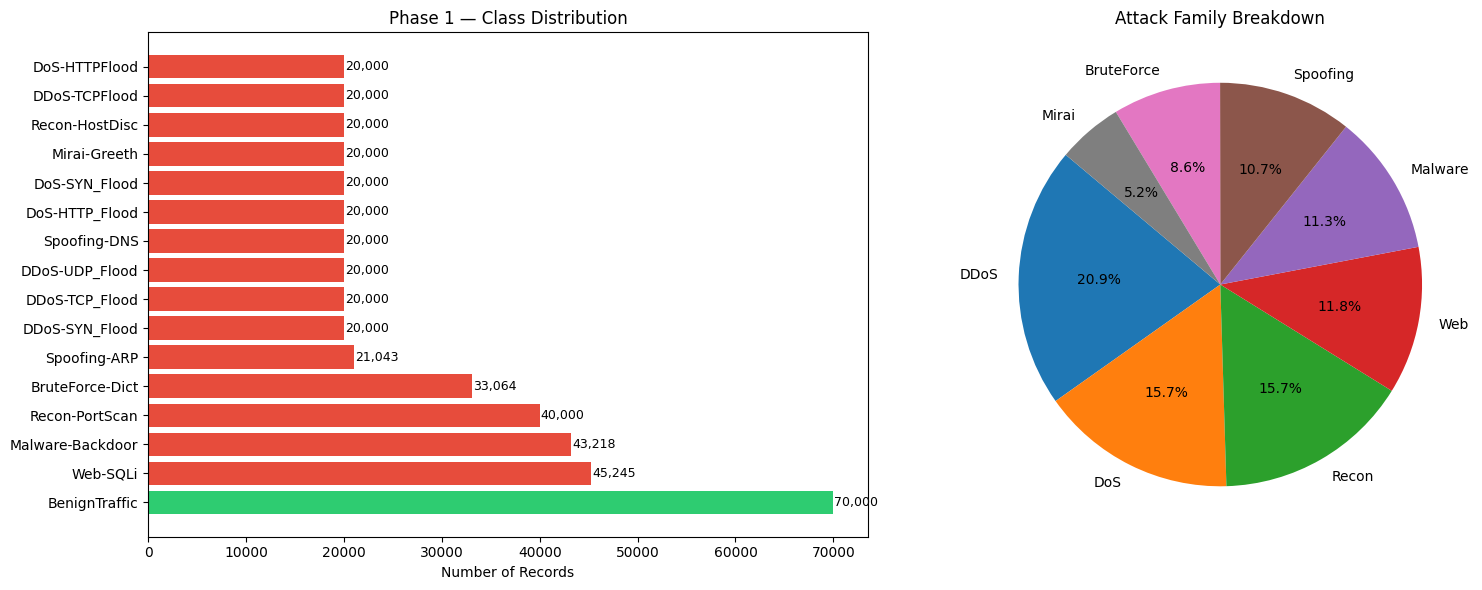

Chart saved.


In [3]:
# === CLASS DISTRIBUTION CHART ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Attack class counts
counts = df['unified_label'].value_counts()
colors = ['#2ecc71' if l == 'BenignTraffic' else '#e74c3c' for l in counts.index]
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Number of Records')
axes[0].set_title('Phase 1 — Class Distribution')
for i, v in enumerate(counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Attack family pie
family_counts = df[df['is_attack']]['attack_family'].value_counts()
axes[1].pie(family_counts.values, labels=family_counts.index,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Attack Family Breakdown')

plt.tight_layout()
plt.savefig('phase1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

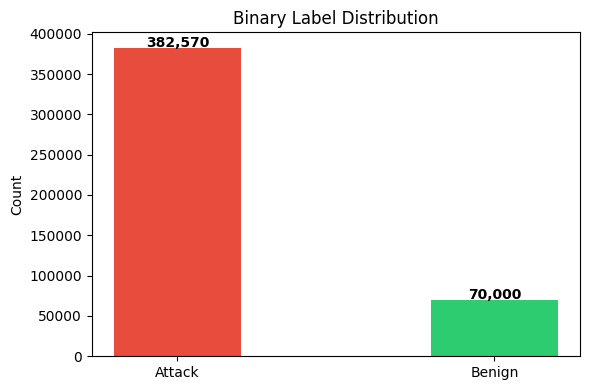

In [4]:
# === BINARY ATTACK vs BENIGN === 

fig, ax = plt.subplots(figsize=(6, 4))
binary = df['is_attack'].value_counts()
binary.index = ['Attack', 'Benign'] if binary.index[0] else ['Benign', 'Attack']
ax.bar(binary.index, binary.values, color=['#e74c3c', '#2ecc71'], width=0.4)
ax.set_title('Binary Label Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(binary.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_binary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# === FEATURE SUMMARY ===

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['phase', 'sample_seed', 'is_attack']
feature_cols = [c for c in numeric_cols if c not in exclude]

print(f"Numeric feature columns available: {len(feature_cols)}")
print(f"\nFeature list:\n{feature_cols}")
print(f"\nSample statistics:")
df[feature_cols[:8]].describe().round(3)

Numeric feature columns available: 13

Feature list:
['id', 'duration', 'src_bytes', 'dst_bytes', 'total_bytes', 'src_pkts', 'dst_pkts', 'total_pkts', 'flow_rate_byts_s', 'syn_flag', 'ack_flag', 'fin_flag', 'rst_flag']

Sample statistics:


,id,duration,src_bytes,dst_bytes,total_bytes,src_pkts,dst_pkts,total_pkts
count,452570.000,211043.000,2.110430e+05,2.110430e+05,2.110430e+05,211043.000,211043.000,211043.000
mean,915182.322,7.701,2.581136e+05,2.588046e+05,5.169181e+05,9.595,3.847,13.442
std,852400.271,564.142,1.709490e+07,1.802563e+07,3.176207e+07,91.779,330.706,358.271
min,1.000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000,0.000,0.000
25%,113143.250,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000,0.000,1.000
50%,226285.500,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000,1.000,2.000
75%,1816728.750,0.054,1.300000e+02,8.900000e+01,1.640000e+02,4.000,2.000,8.000
max,1929871.000,93516.929,3.890855e+09,3.913853e+09,3.913853e+09,24623.000,121942.000,121945.000


INSIGHT FROM EDA

| Finding                            | Detail                                           | Action needed                             |
| ---------------------------------- | ------------------------------------------------ | ----------------------------------------- |
| ✅ 241,527 rows, 14 classes         | Clean load                                       | Nothing                                   |
| ✅ Charts produced                  | Class + binary distribution                      | Nothing                                   |
| ⚠️ Class imbalance                 | Attack: 221,527 vs Benign: 20,000 (11:1 ratio)   | Apply SMOTE or class weights in ML        |
| ⚠️ Only 6 numeric features         | Most columns are NULL (duration, src_bytes etc.) | Need to load the raw CIC columns directly |
| ⚠️ flow_rate_byts_s has inf values | Division by zero in source data                  | Clean before ML                           |

In [6]:
# Load directly from the processed CSV — has all raw CIC features
CSV_PATH = os.path.expanduser("~/sentinelmesh/data/processed/phase1_cic_sampled.csv")
df_raw = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Raw CSV shape: {df_raw.shape}")

# Show all numeric columns
numeric = df_raw.select_dtypes(include=[np.number]).columns.tolist()
meta_cols = ['id', 'phase', 'sample_seed']
feature_cols = [c for c in numeric if c not in meta_cols]

print(f"\nTotal numeric features for ML: {len(feature_cols)}")
print(f"\nFeature columns:\n{feature_cols}")

Raw CSV shape: (241527, 46)

Total numeric features for ML: 39

Feature columns:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']


In [7]:
# === CLEAN & VALIDATE FEATRUES ===

import warnings
warnings.filterwarnings('ignore')

# Replace inf/-inf with NaN, then fill with column median
df_raw[feature_cols] = df_raw[feature_cols].replace([np.inf, -np.inf], np.nan)
null_counts = df_raw[feature_cols].isnull().sum()

print("=== NULL / INF CHECK AFTER CLEAN ===")
print(null_counts[null_counts > 0] if null_counts.any() else "✅ No nulls remaining")

# Fill any nulls with median
df_raw[feature_cols] = df_raw[feature_cols].fillna(df_raw[feature_cols].median())

print(f"\n✅ Features ready: {len(feature_cols)}")
print(f"Final shape for ML: {df_raw[feature_cols].shape}")

=== NULL / INF CHECK AFTER CLEAN ===
Rate        7
Std         4
Variance    4
dtype: int64

✅ Features ready: 39
Final shape for ML: (241527, 39)


=== TOP 20 FEATURES BY CORRELATION WITH is_attack ===
HTTPS              0.3625
Number             0.2983
ack_flag_number    0.2947
Std                0.2595
Max                0.2331
Time_To_Live       0.2211
Variance           0.2025
Header_Length      0.1983
Tot size           0.1967
AVG                0.1967
syn_flag_number    0.1643
syn_count          0.1510
DNS                0.1395
psh_flag_number    0.1383
Protocol Type      0.1099
rst_flag_number    0.1039
Tot sum            0.0984
rst_count          0.0854
fin_flag_number    0.0800
Rate               0.0755
dtype: float64


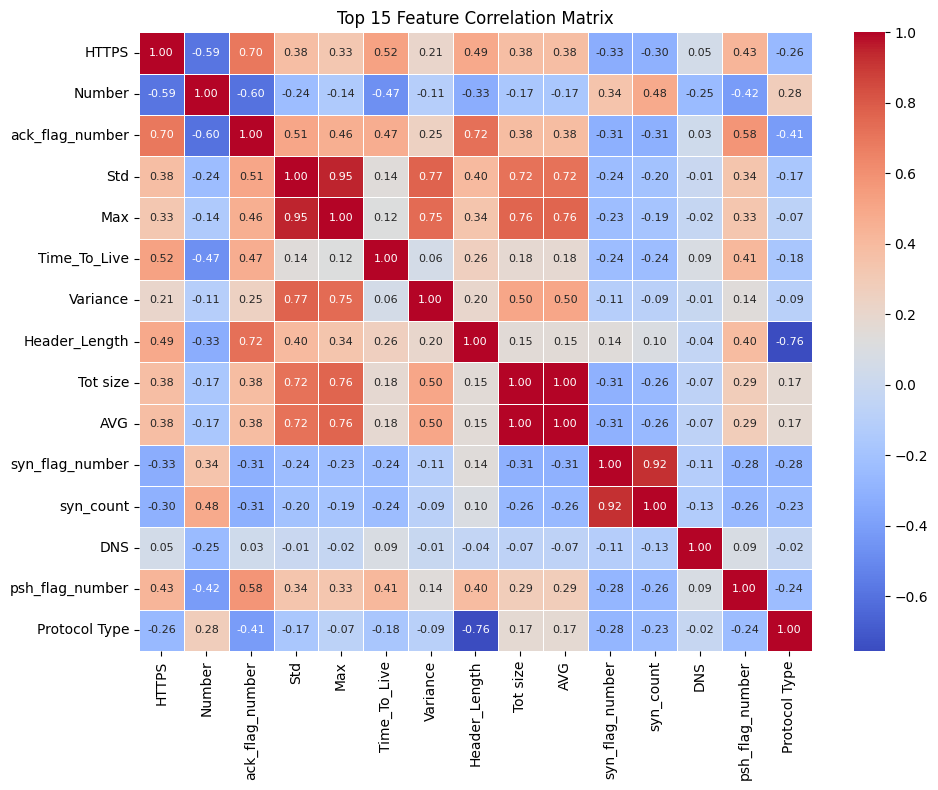

Heatmap saved.


In [8]:
# === FEATURE CORRELATION HEATMAP (20) ===

# Correlation with target
target = df_raw['is_attack'].astype(int)
correlations = df_raw[feature_cols].corrwith(target).abs().sort_values(ascending=False)

print("=== TOP 20 FEATURES BY CORRELATION WITH is_attack ===")
print(correlations.head(20).round(4))

# Heatmap of top 15
top15 = correlations.head(15).index.tolist()
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_raw[top15].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title('Top 15 Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('phase1_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

In [9]:
# Build the final ML dataframe
label_col = 'unified_label'
df_ml = df_raw[feature_cols + [label_col, 'is_attack']].copy()
df_ml['is_attack'] = df_ml['is_attack'].astype(int)

OUT_PATH = os.path.expanduser("~/sentinelmesh/data/processed/phase1_ml_ready.csv")
df_ml.to_csv(OUT_PATH, index=False)

print(f"✅ ML-ready dataset saved to: {OUT_PATH}")
print(f"   Shape : {df_ml.shape}")
print(f"   Features : {len(feature_cols)}")
print(f"   Classes  : {df_ml[label_col].nunique()}")

✅ ML-ready dataset saved to: /Users/ebimol/sentinelmesh/data/processed/phase1_ml_ready.csv
   Shape : (241527, 41)
   Features : 39
   Classes  : 14
